# Extracción de personajes y relaciones en JSON con un LLM local

**Autor:** Jheison Martinez Bolivar  
**Programa:** Maestría en Inteligencia Artificial  
**Actividad:** Despliegue local de un LLM y técnicas de prompt engineering  
**Fecha:** octubre de 2026

## Propósito

El notebook comprueba si un modelo local puede convertir un pasaje narrativo en datos que un programa lea. El texto es el primer capítulo de *Cien años de soledad* (líneas 1–39 de `data/capitulo_01.txt`, unas 4.300 palabras). Al modelo se le pide devolver en JSON los personajes que actúan o hablan y sus relaciones.

La pregunta práctica: ¿qué configuración produce un JSON válido, con personajes y relaciones correctos, sin convertir en personaje a quien solo se menciona?

## Modelo y herramienta

Se decide usar Ollama para correr el modelo en la propia máquina, con `qwen3.5:4b`, uno de los más pequeños de su familia. Un modelo pequeño usa menos memoria, pero tiene más probabilidad de fallar con instrucciones largas; por eso se mide primero la validez del formato y después el contenido.

## Ruta del trabajo

1. **Entorno y datos:** se comprueba Ollama, se carga el pasaje y se escribe la referencia de evaluación.
2. **Prompt engineering:** se personalizan las instrucciones y se definen zero-shot, one-shot y few-shot.
3. **Petición y métricas:** se explica qué se envía y cómo se puntúa la salida.
4. **Hiperparámetros:** `temperature` como base y dos adicionales, `top_p` y `top_k`, con barridos de una perilla.
5. **Comparación de técnicas** con la configuración elegida.
6. **Salida estructurada:** diagnóstico de JSON inválido y esquema `format`.
7. **Conclusiones** por tema y limitaciones.

Cada etapa abre con una hipótesis y cierra con un análisis de la salida. El código no lleva comentarios: cada celda se explica en el texto que la precede.


## 1. Entorno y comprobación del servidor

**Hipótesis:** si Ollama está activo y `qwen3.5:4b` está descargado, `/api/tags` lo listará.

**Código.** Define las constantes del experimento (modelo, rango de líneas, `num_ctx`, `num_predict`, tres semillas) y falla con un mensaje claro si el servidor no responde o falta el modelo. Si la API no responde, se inicia con `ollama serve`; si aparece `address already in use`, ya hay un servidor activo.


In [1]:
import json
import re
import statistics
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import requests

URL = "http://127.0.0.1:11434"
MODELO = "qwen3.5:4b"
RUTA_CAPITULO = Path("data/capitulo_01.txt")
LINEAS = (1, 39)
NUM_CTX = 16384
NUM_PREDICT = 3000
SEMILLAS = [1, 2, 3]
TOP_K_BASE = 40

r = requests.get(f"{URL}/api/tags", timeout=10)
r.raise_for_status()
modelos = [m["name"] for m in r.json()["models"]]
assert MODELO in modelos, f"Falta {MODELO}. Disponibles: {modelos}"
print("Ollama responde. Modelos disponibles:", modelos)


Ollama responde. Modelos disponibles: ['qwen3.5:4b']


**Análisis.** Ollama responde y `qwen3.5:4b` está entre los modelos disponibles. La hipótesis se confirma: las celdas siguientes pueden llamar a la API.


## 2. Pasaje

**Hipótesis:** las líneas 1–39 suman unas 4.300 palabras y caben en la ventana de 16.384 tokens con instrucciones y ejemplos.

**Código.** Lee `data/capitulo_01.txt`, toma el rango y comprueba el tamaño con un `assert`: si el rango cambia por error, el notebook se detiene antes de gastar llamadas.


In [2]:
lineas = RUTA_CAPITULO.read_text(encoding="utf-8").splitlines()
pasaje = "\n".join(lineas[LINEAS[0] - 1 : LINEAS[1]]).strip()
palabras = len(pasaje.split())
print(f"Líneas {LINEAS[0]}–{LINEAS[1]}: {palabras:,} palabras, {len(pasaje):,} caracteres")
assert 4000 <= palabras <= 4600, "El rango de líneas no coincide con el pasaje esperado"


Líneas 1–39: 4,302 palabras, 25,680 caracteres


**Análisis.** El pasaje tiene 4.302 palabras y 25.680 caracteres, dentro del rango esperado. Que quepa en el contexto se confirma en la sección 5: el prompt de zero-shot ocupa 6.632 tokens de entrada, dentro de `num_ctx=16384`.


## 3. Referencia de evaluación

Medir exige una respuesta correcta escrita a mano:

- **Personajes:** quienes actúan o hablan en la escena.
- **Menciones:** nombres que aparecen sin actuar (Francis Drake, la reina Isabel, Moisés…). Si el modelo los devuelve como personajes, cuenta como error.
- **Relaciones:** pares de personajes unidos por un vínculo o una acción.

**Código.** Las tres listas son la referencia. `TITULOS` y `ALIAS` normalizan nombres antes de comparar, para que «Aureliano» y «Aureliano Buendía» cuenten como la misma persona. La segunda celda cuenta cuántas veces aparece cada nombre en el pasaje y se detiene si alguno no aparece; «José Arcadio» incluye las apariciones de «José Arcadio Buendía» porque el conteo es literal.


In [3]:
REFERENCIA_PERSONAJES = [
    "José Arcadio Buendía",
    "Úrsula Iguarán",
    "Melquíades",
    "Aureliano Buendía",
    "José Arcadio",
    "Primer Aureliano Buendía",
]

REFERENCIA_MENCIONADOS = [
    "Monje Hermann",
    "Francis Drake",
    "Reina Isabel",
    "Nostradamus",
    "María la judía",
    "Moisés",
    "Zósimo",
]

REFERENCIA_RELACIONES = [
    ("Úrsula Iguarán", "esposa de", "José Arcadio Buendía"),
    ("Aureliano Buendía", "hijo de", "José Arcadio Buendía"),
    ("José Arcadio", "hermano de", "Aureliano Buendía"),
    ("Primer Aureliano Buendía", "abuelo de", "José Arcadio Buendía"),
    ("José Arcadio Buendía", "compra imanes a", "Melquíades"),
    ("José Arcadio Buendía", "recibe laboratorio de", "Melquíades"),
    ("Úrsula Iguarán", "desconfía de", "Melquíades"),
    ("Melquíades", "resume estudios de", "Monje Hermann"),
    ("José Arcadio Buendía", "envía manual a", "autoridades"),
    ("José Arcadio Buendía", "guía la expedición de", "hombres de Macondo"),
    ("Úrsula Iguarán", "hija de", "padre sin nombre"),
    ("José Arcadio Buendía", "funda", "Macondo"),
]

TITULOS = {"coronel", "don", "dona", "senor", "senora", "maestro", "el", "la", "sir"}

ALIAS = {
    "aureliano": "aureliano buendia",
    "ursula": "ursula iguaran",
    "jose arcadio buendia": "jose arcadio buendia",
    "primero aureliano buendia": "primer aureliano buendia",
}


In [4]:
def normalizar(texto):
    sin_tilde = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    return " ".join(sin_tilde.lower().split())


print(f"{'nombre':30} {'apariciones':>11}")
for nombre in REFERENCIA_PERSONAJES + REFERENCIA_MENCIONADOS:
    n = len(re.findall(re.escape(nombre), pasaje, flags=re.IGNORECASE))
    print(f"{nombre:30} {n:>11}")
    assert n > 0, f"«{nombre}» no aparece en el pasaje"


nombre                         apariciones
José Arcadio Buendía                    23
Úrsula Iguarán                           1
Melquíades                              17
Aureliano Buendía                        3
José Arcadio                            27
Primer Aureliano Buendía                 1
Monje Hermann                            1
Francis Drake                            1
Reina Isabel                             1
Nostradamus                              1
María la judía                           1
Moisés                                   1
Zósimo                                   1


**Análisis.** Todos los nombres de la referencia aparecen en el pasaje. «José Arcadio» suma 27 porque incluye a «José Arcadio Buendía» (23); «Melquíades» aparece 17 veces. La referencia refleja una sola lectura del capítulo, la del autor: otra podría cambiar la lista y afectaría a todas las métricas por igual.


## 4. Prompt engineering: zero-shot, one-shot y few-shot

Las tres condiciones comparten instrucciones, formato y pasaje. Solo cambia el número de ejemplos antes del pasaje: **zero-shot** (0), **one-shot** (1) y **few-shot** (2).

Cada regla del prompt responde a un fallo que se quiere evitar:

| Decisión | Fallo que evita |
|---|---|
| «Solo un objeto JSON, sin texto antes ni después» | Explicaciones que rompen `json.loads` |
| Mostrar la forma exacta con sus claves | Claves inventadas |
| «Solo quienes actúan o hablan; no incluyas menciones» | Convertir a Francis Drake en personaje |
| «El nombre tal como aparece» | Nombres traducidos o completados |
| «No añadas datos que no estén en el pasaje» | Personajes o relaciones inventados |
| Ejemplos con personajes ficticios | Filtrar la respuesta correcta; permiten detectar copias |

**Hipótesis:** con más ejemplos el modelo seguirá mejor el formato y la regla de personajes, aunque podría copiar nombres de los ejemplos (se contarán como extras).

**Código.** `INSTRUCCIONES` y los ejemplos son constantes; `construir_prompt(condicion)` es la única función que cambia entre condiciones. La segunda celda comprueba, sin llamar al modelo, que solo varía el número de ejemplos. Todo se envía en un único mensaje `user`.


In [5]:
INSTRUCCIONES = """Eres un extractor de información. Lee el pasaje de la novela y responde solo con un objeto JSON válido, sin texto antes ni después, con esta forma:

{"personajes": [{"nombre": "..."}],
 "relaciones": [{"sujeto": "...", "relacion": "...", "objeto": "..."}]}

Reglas:
- "personajes": solo quienes actúan o hablan en el pasaje. No incluyas a quienes solo se mencionan.
- "nombre": el nombre tal como aparece en el texto.
- "relaciones": vínculos de parentesco, encargos, acciones o lugares entre dos personajes, o entre un personaje y otro elemento del pasaje.
- No añadas datos que no estén en el pasaje.
"""

EJEMPLO_1 = {
    "pasaje": "Elena Castro llegó a Villamar en marzo con una carta de su hermano Julián, que había muerto en el mar. El alcalde, Ramón Soto, la recibió con desconfianza, pero le dio la llave de la biblioteca.",
    "salida": {
        "personajes": [{"nombre": "Elena Castro"}, {"nombre": "Ramón Soto"}],
        "relaciones": [
            {"sujeto": "Elena Castro", "relacion": "hermana de", "objeto": "Julián"},
            {"sujeto": "Ramón Soto", "relacion": "alcalde de", "objeto": "Villamar"},
        ],
    },
}

EJEMPLO_2 = {
    "pasaje": "En la plaza, el maestro Ignacio Vera enseñó a leer a Lucía, la hija del alcalde Ramón Soto.",
    "salida": {
        "personajes": [{"nombre": "Ignacio Vera"}, {"nombre": "Lucía"}, {"nombre": "Ramón Soto"}],
        "relaciones": [
            {"sujeto": "Ignacio Vera", "relacion": "enseña a leer a", "objeto": "Lucía"},
            {"sujeto": "Lucía", "relacion": "hija de", "objeto": "Ramón Soto"},
        ],
    },
}


def bloque_ejemplo(i, ejemplo):
    salida = json.dumps(ejemplo["salida"], ensure_ascii=False)
    return f"Ejemplo {i}\nPasaje:\n{ejemplo['pasaje']}\nSalida:\n{salida}"


def construir_prompt(condicion):
    ejemplos = {"zero": [], "one": [EJEMPLO_1], "few": [EJEMPLO_1, EJEMPLO_2]}[condicion]
    partes = [INSTRUCCIONES]
    if ejemplos:
        partes.append("Ejemplos:\n\n" + "\n\n".join(bloque_ejemplo(i, e) for i, e in enumerate(ejemplos, 1)))
    partes.append("Pasaje a procesar:\n" + pasaje)
    return "\n\n".join(partes)


In [6]:
for condicion in ["zero", "one", "few"]:
    prompt = construir_prompt(condicion)
    print(f"{condicion:5} caracteres={len(prompt):>7,}  ejemplos={prompt.count('Ejemplo ')}  "
          f"termina con el pasaje={prompt.endswith(pasaje)}")


zero  caracteres= 26,304  ejemplos=0  termina con el pasaje=True
one   caracteres= 26,772  ejemplos=1  termina con el pasaje=True
few   caracteres= 27,145  ejemplos=2  termina con el pasaje=True


**Análisis.** Las tres condiciones tienen la misma instrucción y el pasaje al final; los ejemplos añaden 468 caracteres (one-shot) y 841 (few-shot) a zero-shot. Queda verificado que la única variable es el número de ejemplos. La hipótesis sobre la calidad se resuelve en las secciones 9 y 12.


## 5. Anatomía de una petición

Una petición a `/api/chat` es una lista de mensajes con `role` y `content`. Aquí se envía un solo mensaje `user`. Lo demás va en `options`:

- `temperature`, `top_p`, `top_k`: controlan la elección de la siguiente palabra (sección 8).
- `seed`: fija el muestreo para repetir una petición.
- `num_ctx`: ventana de contexto en tokens.
- `num_predict`: máximo de tokens de salida; no obliga a usarlos.

`stream=False` devuelve la respuesta completa y `think=False` oculta el razonamiento interno, para medir solo la respuesta visible.

**Hipótesis:** la respuesta llegará con `done_reason="stop"` y los contadores confirmarán que el prompt cabe en `num_ctx`.

**Código.** `payload` arma el cuerpo de la petición, `llamar` la envía y devuelve la respuesta, y la celda imprime la estructura (con el mensaje recortado) y hace una primera llamada real.


In [7]:
def payload(prompt, temperature, top_p, seed, top_k=TOP_K_BASE):
    return {
        "model": MODELO,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "think": False,
        "options": {
            "temperature": temperature,
            "top_p": top_p,
            "top_k": top_k,
            "seed": seed,
            "num_ctx": NUM_CTX,
            "num_predict": NUM_PREDICT,
        },
    }


def llamar(prompt, temperature, top_p, seed, top_k=TOP_K_BASE):
    r = requests.post(f"{URL}/api/chat", json=payload(prompt, temperature, top_p, seed, top_k), timeout=1200)
    r.raise_for_status()
    return r.json()


vista = payload(construir_prompt("zero"), 0.2, 0.8, 1)
vista["messages"][0]["content"] = vista["messages"][0]["content"][:300] + " [...]"
print(json.dumps(vista, ensure_ascii=False, indent=2))

d1 = llamar(construir_prompt("zero"), 0.2, 0.8, 1)
print(
    f"tokens de entrada: {d1['prompt_eval_count']:,}  "
    f"de salida: {d1['eval_count']:,}  "
    f"motivo: {d1['done_reason']}  "
    f"tiempo: {d1['total_duration'] / 1e9:.1f} s"
)
print(d1["message"]["content"][:800])


{
  "model": "qwen3.5:4b",
  "messages": [
    {
      "role": "user",
      "content": "Eres un extractor de información. Lee el pasaje de la novela y responde solo con un objeto JSON válido, sin texto antes ni después, con esta forma:\n\n{\"personajes\": [{\"nombre\": \"...\"}],\n \"relaciones\": [{\"sujeto\": \"...\", \"relacion\": \"...\", \"objeto\": \"...\"}]}\n\nReglas:\n- \"personajes\": solo quienes actúa [...]"
    }
  ],
  "stream": false,
  "think": false,
  "options": {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "seed": 1,
    "num_ctx": 16384,
    "num_predict": 3000
  }
}


tokens de entrada: 6,632  de salida: 420  motivo: stop  tiempo: 5.3 s
{"personajes": [{"nombre": "Aureliano Buendía"}, {"nombre": "José Arcadio Buendía"}, {"nombre": "Úrsula Iguarán"}, {"nombre": "Melquíades"}, {"nombre": "Sir Francis Drake"}, {"nombre": "Hermann"}], "relaciones": [{"sujeto": "Aureliano Buendía", "relacion": "es hijo de", "objeto": "José Arcadio Buendía"}, {"sujeto": "José Arcadio Buendía", "relacion": "es padre de", "objeto": "Aureliano Buendía"}, {"sujeto": "José Arcadio Buendía", "relacion": "es esposo de", "objeto": "Úrsula Iguarán"}, {"sujeto": "Melquíades", "relacion": "enseñó a", "objeto": "José Arcadio Buendía"}, {"sujeto": "Melquíades", "relacion": "le devolvió los doblones a cambio de la lupa, y le dejó además unos mapas portugueses y varios instrumentos de navegación", "objeto": "José Arcadio Buendía"}, {"sujeto": "José Arcadio Bu


**Análisis.** La respuesta terminó con `done_reason=stop` y 420 tokens de salida; con 6.632 de entrada, el prompt cabe en el contexto y `num_predict` no limitó nada. La hipótesis se cumple.

Ya aparecen dos fallos: incluye a «Sir Francis Drake», una mención, y «Hermann», que no coincide con «Monje Hermann» y cuenta como extra. Algunas relaciones son frases largas, pero el texto de la relación no entra en el puntaje.


## 6. Métricas

1. **JSON válido:** `json.loads` lo lee y tiene la forma del esquema. Una salida inválida puntúa 0.
2. **Contenido:**
   - **Personajes:** precisión (de los devueltos, cuántos están en la referencia) y cobertura (de la referencia, cuántos devuelve).
   - **Relaciones:** se compara el par de entidades, sin sentido ni texto de la relación.
   - **Errores de mención:** menciones devueltas como personajes.
   - **Extras:** personajes que no están en la referencia ni en las menciones.

El puntaje es el promedio de F1 de personajes y de relaciones.

**Hipótesis de validación:** la referencia puntúa 1.0 contra sí misma y una mención extra cuenta como error. Si no, la métrica está mal.

**Código.** `parsear` valida JSON y esquema, `canon` normaliza nombres, `evaluar` calcula las métricas y la celda ejecuta las dos pruebas de cordura con `assert`.


In [8]:
def parsear(texto):
    limpio = re.sub(r"^```(?:json)?\s*|\s*```$", "", texto.strip())
    try:
        obj = json.loads(limpio)
    except json.JSONDecodeError:
        return None
    esquema_ok = (
        isinstance(obj, dict)
        and isinstance(obj.get("personajes"), list)
        and isinstance(obj.get("relaciones"), list)
        and all(isinstance(p, dict) and isinstance(p.get("nombre"), str) for p in obj["personajes"])
        and all(isinstance(r, dict) and {"sujeto", "relacion", "objeto"} <= r.keys() for r in obj["relaciones"])
    )
    return obj if esquema_ok else None


def canon(nombre):
    partes = normalizar(nombre).split()
    while partes and partes[0] in TITULOS:
        partes.pop(0)
    n = " ".join(partes)
    return ALIAS.get(n, n)


def f1(p, r):
    return 2 * p * r / (p + r) if p + r else 0.0


def evaluar(texto):
    obj = parsear(texto)
    if obj is None:
        return {"json_valido": False, "f1_personajes": 0.0, "f1_relaciones": 0.0, "puntaje": 0.0,
                "errores_mencion": 0, "extras": 0, "n_personajes": 0, "n_relaciones": 0}

    ref_p = {canon(x) for x in REFERENCIA_PERSONAJES}
    men = {canon(x) for x in REFERENCIA_MENCIONADOS}
    pred_p = {canon(p["nombre"]) for p in obj["personajes"]}
    tp = len(pred_p & ref_p)
    p_pers = tp / len(pred_p) if pred_p else 0.0
    r_pers = tp / len(ref_p)

    ref_r = {frozenset((canon(s), canon(o))) for s, _, o in REFERENCIA_RELACIONES}
    pred_r = [frozenset((canon(r["sujeto"]), canon(r["objeto"]))) for r in obj["relaciones"]]
    p_rel = sum(par in ref_r for par in pred_r) / len(pred_r) if pred_r else 0.0
    r_rel = len(set(pred_r) & ref_r) / len(ref_r)

    f_p, f_r = f1(p_pers, r_pers), f1(p_rel, r_rel)
    return {
        "json_valido": True,
        "p_personajes": p_pers, "r_personajes": r_pers, "f1_personajes": f_p,
        "p_relaciones": p_rel, "r_relaciones": r_rel, "f1_relaciones": f_r,
        "puntaje": (f_p + f_r) / 2,
        "errores_mencion": len(pred_p & men),
        "extras": len(pred_p - ref_p - men),
        "n_personajes": len(pred_p), "n_relaciones": len(pred_r),
    }


perfecto = {
    "personajes": [{"nombre": n} for n in REFERENCIA_PERSONAJES],
    "relaciones": [{"sujeto": s, "relacion": r, "objeto": o} for s, r, o in REFERENCIA_RELACIONES],
}
m = evaluar(json.dumps(perfecto))
assert m["f1_personajes"] == 1.0 and m["f1_relaciones"] == 1.0, m

con_mencion = json.loads(json.dumps(perfecto))
con_mencion["personajes"].append({"nombre": "Monje Hermann"})
m2 = evaluar(json.dumps(con_mencion))
assert m2["errores_mencion"] == 1 and m2["f1_personajes"] < 1.0, m2
print("Referencia contra sí misma: puntaje", m["puntaje"])
print("Con una mención extra: errores de mención", m2["errores_mencion"], "F1 personajes", round(m2["f1_personajes"], 3))


Referencia contra sí misma: puntaje 1.0
Con una mención extra: errores de mención 1 F1 personajes 0.923


**Análisis.** Las dos pruebas pasaron: la referencia puntúa 1.0 y una mención extra baja la F1 de personajes a 0.923 y cuenta como error. Límite: la comparación es por nombre completo, así que una mención escrita de forma parcial («Hermann») cuenta como extra y no como error, lo que subestima los errores de mención.


## 7. Repetibilidad

**Hipótesis:** dos llamadas con el mismo prompt, `temperature=0.2`, `top_p=0.8` y `seed=1` darán el mismo texto. Si no, las diferencias entre semillas deben leerse con cautela.

**Código.** Repite la llamada de la sección 5 y compara ambos textos.


In [9]:
d2 = llamar(construir_prompt("zero"), 0.2, 0.8, 1)
print("salidas idénticas:", d1["message"]["content"] == d2["message"]["content"])

salidas idénticas: True


**Análisis.** Las dos llamadas dieron exactamente el mismo texto. La hipótesis se confirma para este equipo, modelo y versión de Ollama: con la misma semilla la generación es reproducible. Por tanto, las diferencias entre semillas de las secciones siguientes son efecto de la semilla y no ruido de ejecución.


## 8. Hiperparámetros: `temperature`, `top_p` y `top_k`

Al elegir la siguiente palabra, el modelo asigna una probabilidad a cada candidato. Tres controles deciden cuáles compiten:

- **`temperature`** (base) reescala las probabilidades: baja, gana casi siempre el más probable; alta, los improbables tienen más opción.
- **`top_k`** (adicional) conserva solo los *k* candidatos más probables.
- **`top_p`** (adicional) conserva el grupo más pequeño cuya probabilidad acumulada llega a *p*.

Con probabilidades `[0.50, 0.30, 0.10, 0.05, 0.05]`: `top_k=2` y `top_p=0.8` conservan los dos primeros; `top_p=0.95` conserva cuatro. `top_k` fija una cantidad y `top_p` fija una masa de probabilidad. Ollama aplica ambos, así que manda el más restrictivo (por defecto, `top_k=40` y `top_p=0.9`).

**Diseño.** Cada barrido cambia una perilla y deja las otras en su base (`temperature=0.7`, `top_p=0.95`, `top_k=40`), con tres semillas por nivel y en few-shot, la condición más estable. Niveles: `temperature` 0.2 · 0.7 · 1.5; `top_p` 0.3 · 0.7 · 0.95; `top_k` 10 · 40 · 100 (27 llamadas). Regla de decisión: el valor base cambia solo si otro nivel mejora el puntaje medio en más de 0.05, porque con tres semillas una diferencia menor es ruido.

**Hipótesis:** (1) `temperature=1.5` degrada validez y puntaje; entre 0.2 y 0.7 no habrá diferencia clara. (2) `top_p=0.3` reduce la variación entre semillas. (3) `top_k` tendrá poco efecto si `top_p=0.95` ya restringe el grupo.

**Código.** `correr` hace una llamada y la evalúa. El bucle recorre cada perilla y nivel, imprime validez y puntaje medio y aplica la regla de decisión. La segunda celda imprime una tabla (validez, puntaje y menciones por nivel) y grafica media y desviación.


In [10]:
def correr(condicion, temperature, top_p, seed, top_k=TOP_K_BASE):
    d = llamar(construir_prompt(condicion), temperature, top_p, seed, top_k)
    texto = d["message"]["content"]
    return {
        **evaluar(texto),
        "condicion": condicion, "temperature": temperature, "top_p": top_p, "top_k": top_k, "seed": seed,
        "segundos": d["total_duration"] / 1e9,
        "tokens_entrada": d["prompt_eval_count"], "tokens_salida": d["eval_count"],
        "motivo": d["done_reason"], "texto": texto,
    }


BASE = {"temperature": 0.7, "top_p": 0.95, "top_k": TOP_K_BASE}
NIVELES = {"temperature": [0.2, 0.7, 1.5], "top_p": [0.3, 0.7, 0.95], "top_k": [10, 40, 100]}
MARGEN = 0.05

barrido = []
elegido = dict(BASE)
for perilla, niveles in NIVELES.items():
    medias = {}
    for nivel in niveles:
        config = {**BASE, perilla: nivel}
        corridas = [{**correr("few", seed=s, **config), "barrido": perilla} for s in SEMILLAS]
        barrido.extend(corridas)
        medias[nivel] = statistics.mean(r["puntaje"] for r in corridas)
        validas = sum(r["json_valido"] for r in corridas)
        print(f"{perilla:11} = {nivel:<5} JSON válido {validas}/3   puntaje medio {medias[nivel]:.3f}")
    mejor = max(medias, key=medias.get)
    if medias[mejor] - medias[BASE[perilla]] > MARGEN:
        elegido[perilla] = mejor
    destino = "se mantiene" if elegido[perilla] == BASE[perilla] else "cambia a"
    print(f"  -> {perilla}: {destino} {elegido[perilla]}\n")

TEMPERATURE, TOP_P, TOP_K = elegido["temperature"], elegido["top_p"], elegido["top_k"]
print(f"Fijado para las siguientes secciones: temperature={TEMPERATURE}, top_p={TOP_P}, top_k={TOP_K}")


temperature = 0.2   JSON válido 3/3   puntaje medio 0.472


temperature = 0.7   JSON válido 3/3   puntaje medio 0.535


temperature = 1.5   JSON válido 2/3   puntaje medio 0.338
  -> temperature: se mantiene 0.7



top_p       = 0.3   JSON válido 3/3   puntaje medio 0.531


top_p       = 0.7   JSON válido 3/3   puntaje medio 0.558


top_p       = 0.95  JSON válido 3/3   puntaje medio 0.535
  -> top_p: se mantiene 0.95



top_k       = 10    JSON válido 3/3   puntaje medio 0.497


top_k       = 40    JSON válido 3/3   puntaje medio 0.535


top_k       = 100   JSON válido 2/3   puntaje medio 0.378
  -> top_k: se mantiene 40

Fijado para las siguientes secciones: temperature=0.7, top_p=0.95, top_k=40


perilla      nivel  JSON válido   puntaje (media ± sd)  menciones
temperature    0.2          3/3           0.47 ± 0.05       2.67
temperature    0.7          3/3           0.53 ± 0.03       1.33
temperature    1.5          2/3           0.34 ± 0.29       0.67
top_p          0.3          3/3           0.53 ± 0.00       1.00
top_p          0.7          3/3           0.56 ± 0.05       1.33
top_p         0.95          3/3           0.53 ± 0.03       1.33
top_k           10          3/3           0.50 ± 0.07       1.33
top_k           40          3/3           0.53 ± 0.03       1.33
top_k          100          2/3           0.38 ± 0.33       1.00


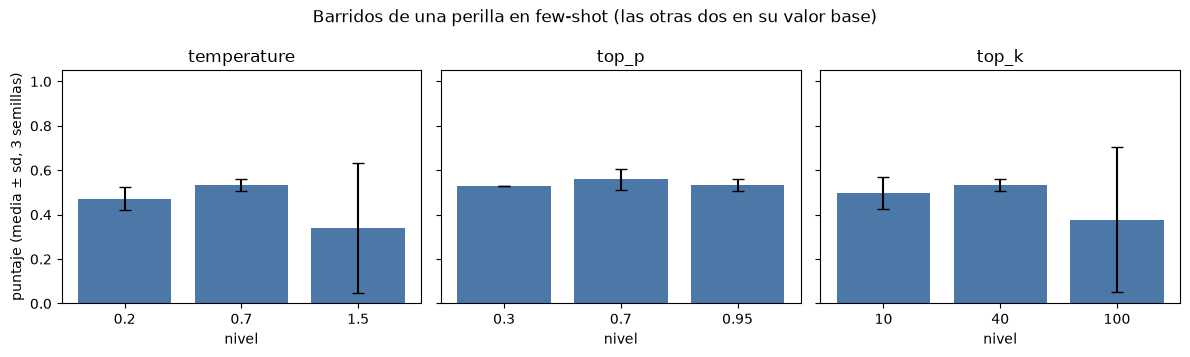

In [11]:
print(f"{'perilla':11} {'nivel':>6} {'JSON válido':>12} {'puntaje (media ± sd)':>22} {'menciones':>10}")
for perilla, niveles in NIVELES.items():
    for nivel in niveles:
        filas = [r for r in barrido if r["barrido"] == perilla and r[perilla] == nivel]
        puntajes = [r["puntaje"] for r in filas]
        validas = sum(r["json_valido"] for r in filas)
        menciones = statistics.mean(r["errores_mencion"] for r in filas)
        print(f"{perilla:11} {nivel:>6} {validas:>10}/3 {statistics.mean(puntajes):>14.2f} ± {statistics.stdev(puntajes):.2f} {menciones:>10.2f}")

fig, ejes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (perilla, niveles) in zip(ejes, NIVELES.items()):
    medias, desviaciones = [], []
    for nivel in niveles:
        puntajes = [r["puntaje"] for r in barrido if r["barrido"] == perilla and r[perilla] == nivel]
        medias.append(statistics.mean(puntajes))
        desviaciones.append(statistics.stdev(puntajes))
    ax.bar([str(n) for n in niveles], medias, yerr=desviaciones, capsize=4, color="#4c78a8")
    ax.set_title(perilla)
    ax.set_xlabel("nivel")
ejes[0].set_ylabel("puntaje (media ± sd, 3 semillas)")
ejes[0].set_ylim(0, 1.05)
plt.suptitle("Barridos de una perilla en few-shot (las otras dos en su valor base)")
plt.tight_layout()
plt.show()


**Análisis.** Con la regla de decisión, ninguna perilla cambió su valor base. Resultado por hipótesis:

1. **`temperature`: confirmada en parte.** `1.5` degrada (0.34 ± 0.29, una corrida inválida). `0.2` también quedó por debajo de `0.7` (0.47 frente a 0.53) y con el doble de menciones (2.67 frente a 1.33), más de lo previsto.
2. **`top_p`: sin efecto claro.** Los tres niveles quedan entre 0.53 y 0.56. `0.3` dio la menor dispersión (0.00), pero `0.7` dio más que `0.95` (0.05 frente a 0.03); no hay tendencia.
3. **`top_k`: rechazada.** `10` y `40` son parecidos (0.50 y 0.53), pero `100` degradó (0.38 ± 0.33, una corrida inválida). Con tres semillas no se separa un efecto real del ruido de una sola semilla.

Lo sólido es poco: `temperature=1.5` y `top_k=100` fueron los únicos niveles que rompieron el JSON, y los valores intermedios no se distinguen entre sí.


## 9. Zero-shot, one-shot y few-shot con la configuración elegida

Con los valores fijados en la sección 8, cada condición corre con tres semillas (nueve llamadas). Solo cambia el número de ejemplos.

**Hipótesis:** one-shot y few-shot superarán a zero-shot en validez del JSON y en la regla de menciones; si few-shot copia nombres de los ejemplos, subirán los extras.

**Código.** Recorre las tres condiciones y semillas con `correr` e imprime las métricas de cada corrida.


In [12]:
resultados = []
for cond in ["zero", "one", "few"]:
    for s in SEMILLAS:
        r = correr(cond, TEMPERATURE, TOP_P, s, TOP_K)
        resultados.append(r)
        print(f"{cond:5} seed={s}: json={r['json_valido']} f1_pers={r['f1_personajes']:.2f} "
              f"f1_rel={r['f1_relaciones']:.2f} menciones={r['errores_mencion']} "
              f"tokens_salida={r['tokens_salida']} {r['segundos']:.0f}s")


zero  seed=1: json=True f1_pers=0.73 f1_rel=0.40 menciones=1 tokens_salida=683 8s


zero  seed=2: json=False f1_pers=0.00 f1_rel=0.00 menciones=0 tokens_salida=334 4s


zero  seed=3: json=False f1_pers=0.00 f1_rel=0.00 menciones=0 tokens_salida=400 4s


one   seed=1: json=True f1_pers=0.67 f1_rel=0.51 menciones=1 tokens_salida=282 4s


one   seed=2: json=True f1_pers=0.50 f1_rel=0.35 menciones=2 tokens_salida=429 5s


one   seed=3: json=True f1_pers=0.71 f1_rel=0.46 menciones=1 tokens_salida=602 7s


few   seed=1: json=True f1_pers=0.67 f1_rel=0.39 menciones=2 tokens_salida=276 4s


few   seed=2: json=True f1_pers=0.62 f1_rel=0.41 menciones=1 tokens_salida=286 3s


few   seed=3: json=True f1_pers=0.83 f1_rel=0.30 menciones=1 tokens_salida=257 3s


**Análisis.** Zero-shot solo fue válido 1 de 3 veces (puntaje 0.19 ± 0.32). One-shot y few-shot fueron válidos 3 de 3, con el mismo puntaje medio (0.53): one-shot tiene mejor F1 de relaciones (0.44 frente a 0.36) y few-shot mejor F1 de personajes (0.71 frente a 0.63), dentro de la desviación.

La hipótesis se cumple en la validez, pero los ejemplos no mejoraron la regla de menciones (1.33 por corrida en ambas). El riesgo de copia apareció una vez: few-shot con la semilla 2 devolvió «Julián» y «Ramón Soto», de los ejemplos.


## 10. Diagnóstico de salidas inválidas

Si la sección 9 deja JSON cortado al final, hay dos explicaciones posibles:

1. **`num_predict` corta la respuesta:** el motivo de parada será `length` y subir el límite lo arreglará.
2. **El modelo termina sin cerrar el objeto:** el motivo será `stop` y el límite no tendrá efecto.

**Código.** `llamar_con` permite cambiar `num_predict` y añadir `format`; `clasificar` devuelve el error de `json.loads` y el final del texto. La primera celda reintenta zero-shot con semillas nuevas (+100, hasta tres intentos); la segunda sube `num_predict` a 8.000 para las semillas 2 y 3.


In [13]:
def llamar_con(prompt, temperature, top_p, seed, predict=None, esquema=None):
    p = payload(prompt, temperature, top_p, seed, TOP_K)
    if predict:
        p["options"]["num_predict"] = predict
    if esquema:
        p["format"] = esquema
    r = requests.post(f"{URL}/api/chat", json=p, timeout=1200)
    r.raise_for_status()
    return r.json()


def clasificar(texto):
    limpio = re.sub(r"^```(?:json)?\s*|\s*```$", "", texto.strip())
    try:
        json.loads(limpio)
        return "ok", ""
    except json.JSONDecodeError as e:
        return e.msg, texto.strip()[-30:]


print(f"{'semilla':>8} {'intento':>7} {'motivo':>7} {'tokens':>7}  {'error JSON':<28} final de la salida")
for base in [2, 3]:
    for intento in range(3):
        s_ = base + 100 * intento
        d = llamar_con(construir_prompt("zero"), TEMPERATURE, TOP_P, s_)
        error, cola = clasificar(d["message"]["content"])
        print(f"{s_:>8} {intento + 1:>7} {d['done_reason']:>7} {d['eval_count']:>7}  {error:<28} {cola!r}")
        if error == "ok":
            break


 semilla intento  motivo  tokens  error JSON                   final de la salida


       2       1    stop     334  Expecting ',' delimiter      ' "objeto": "la reina Isabel"}]'


     102       2    stop     447  ok                           ''


       3       1    stop     400  Expecting ',' delimiter      'objeto": "Aureliano Buendía"}]'


     103       2    stop     317  Expecting ',' delimiter      'storia de Sir Francis Drake"}]'


     203       3    stop     270  Expecting ',' delimiter      'eto": "José Arcadio Buendía"}]'


In [14]:
print(f"num_predict actual: {NUM_PREDICT}. Subido a 8000 para las semillas 2 y 3:\n")
for base in [2, 3]:
    d = llamar_con(construir_prompt("zero"), TEMPERATURE, TOP_P, base, predict=8000)
    error, cola = clasificar(d["message"]["content"])
    print(f"seed={base}: motivo={d['done_reason']} tokens={d['eval_count']} error={error!r} final={cola!r}")

num_predict actual: 3000. Subido a 8000 para las semillas 2 y 3:



seed=2: motivo=stop tokens=334 error="Expecting ',' delimiter" final=' "objeto": "la reina Isabel"}]'


seed=3: motivo=stop tokens=400 error="Expecting ',' delimiter" final='objeto": "Aureliano Buendía"}]'


**Análisis.** La hipótesis 1 queda descartada: con `num_predict=8000`, las semillas 2 y 3 dieron los mismos 334 y 400 tokens y el mismo error, y todas las salidas inválidas terminaron en `stop`. La hipótesis 2 se confirma: el modelo cierra la lista de relaciones con `]` y omite la llave final `}`. El reintento con otra semilla recuperó JSON válido en 1 de 5 intentos, así que reintentar no es una solución fiable.


## 11. Salida estructurada con el esquema `format`

`format` acepta un JSON Schema y restringe la decodificación: el modelo solo produce tokens que lo respeten. Fija la forma, no el contenido, y no impide que `num_predict` corte la salida.

**Hipótesis:** con `format`, zero-shot y few-shot serán válidos en las tres semillas; falta ver si mejora también el contenido.

**Código.** `ESQUEMA` describe la forma que pide el prompt. Cada condición se ejecuta con las mismas semillas y parámetros que en la sección 9, añadiendo solo `format`. La segunda celda compara validez, puntaje y menciones con y sin esquema.


In [15]:
ESQUEMA = {
    "type": "object",
    "properties": {
        "personajes": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {"nombre": {"type": "string"}},
                "required": ["nombre"],
            },
        },
        "relaciones": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "sujeto": {"type": "string"},
                    "relacion": {"type": "string"},
                    "objeto": {"type": "string"},
                },
                "required": ["sujeto", "relacion", "objeto"],
            },
        },
    },
    "required": ["personajes", "relaciones"],
}

con_formato = []
for cond in ["zero", "few"]:
    for s in SEMILLAS:
        d = llamar_con(construir_prompt(cond), TEMPERATURE, TOP_P, s, esquema=ESQUEMA)
        texto = d["message"]["content"]
        con_formato.append({**evaluar(texto), "condicion": cond, "seed": s,
                            "motivo": d["done_reason"], "tokens_salida": d["eval_count"], "texto": texto})
        print(f"{cond:5} seed={s}: motivo={d['done_reason']} tokens={d['eval_count']} json={con_formato[-1]['json_valido']} puntaje={con_formato[-1]['puntaje']:.2f}")

zero  seed=1: motivo=stop tokens=683 json=True puntaje=0.56


zero  seed=2: motivo=stop tokens=336 json=True puntaje=0.49


zero  seed=3: motivo=stop tokens=402 json=True puntaje=0.38


few   seed=1: motivo=stop tokens=373 json=True puntaje=0.48


few   seed=2: motivo=stop tokens=286 json=True puntaje=0.51


few   seed=3: motivo=stop tokens=257 json=True puntaje=0.56


In [16]:
print(f"{'condición':10} {'formato':>8} {'JSON válido':>12} {'puntaje medio':>14} {'menciones':>10}")
for cond in ["zero", "few"]:
    for nombre, filas in [("no", resultados), ("sí", con_formato)]:
        f = [r for r in filas if r["condicion"] == cond]
        validez = sum(r["json_valido"] for r in f) / len(f)
        print(f"{cond:10} {nombre:>8} {validez:>12.2f} {statistics.mean(r['puntaje'] for r in f):>14.2f} "
              f"{statistics.mean(r['errores_mencion'] for r in f):>10.2f}")

condición   formato  JSON válido  puntaje medio  menciones
zero             no         0.33           0.19       0.33
zero             sí         1.00           0.48       2.33
few              no         1.00           0.53       1.33
few              sí         1.00           0.52       0.67


**Análisis.** Con `format`, zero-shot pasa de 1 a 3 corridas válidas y de 0.19 a 0.48 de puntaje: la hipótesis se confirma en la forma. Pero las menciones suben de 0.33 a 2.33 por corrida; el 0.33 anterior era bajo solo porque las salidas inválidas puntúan 0 y no se pueden contar. Con few-shot, la validez ya era completa; el puntaje no cambia (0.53 frente a 0.52) y las menciones bajan de 1.33 a 0.67. `format` arregla la forma, no el criterio de personajes.


## 12. Resultados

Media ± desviación típica entre las tres semillas, con la configuración de la sección 8.

**Hipótesis:** el orden será few-shot ≥ one-shot ≥ zero-shot, y `format` subirá la validez de zero-shot.

**Código.** `ms` da formato a media ± desviación; la primera celda es la tabla por condición, la segunda lista los nombres fuera de la referencia (invenciones o copias de ejemplos) y la tercera es el gráfico de F1.


In [17]:
def ms(valores):
    media = statistics.mean(valores)
    sd = statistics.stdev(valores) if len(valores) > 1 else 0.0
    return f"{media:.2f} ± {sd:.2f}"


cabecera = f"{'condición':10} {'JSON válido':>12} {'F1 personajes':>16} {'F1 relaciones':>16} {'puntaje':>16} {'menciones':>10} {'extras':>8} {'tokens salida':>14}"
print(cabecera)
print("-" * len(cabecera))
for cond in ["zero", "one", "few"]:
    filas = [r for r in resultados if r["condicion"] == cond]
    validez = sum(r["json_valido"] for r in filas) / len(filas)
    print(
        f"{cond:10} {validez:>12.2f} "
        f"{ms([r['f1_personajes'] for r in filas]):>16} "
        f"{ms([r['f1_relaciones'] for r in filas]):>16} "
        f"{ms([r['puntaje'] for r in filas]):>16} "
        f"{statistics.mean(r['errores_mencion'] for r in filas):>10.2f} "
        f"{statistics.mean(r['extras'] for r in filas):>8.2f} "
        f"{statistics.mean(r['tokens_salida'] for r in filas):>14.0f}"
    )

condición   JSON válido    F1 personajes    F1 relaciones          puntaje  menciones   extras  tokens salida
-------------------------------------------------------------------------------------------------------------
zero               0.33      0.24 ± 0.42      0.13 ± 0.23      0.19 ± 0.32       0.33     0.00            472
one                1.00      0.63 ± 0.11      0.44 ± 0.08      0.53 ± 0.09       1.33     1.33            438
few                1.00      0.71 ± 0.11      0.36 ± 0.06      0.53 ± 0.03       1.33     0.67            273


In [18]:
ref_todos = {canon(x) for x in REFERENCIA_PERSONAJES + REFERENCIA_MENCIONADOS}
for r in resultados:
    if not r["json_valido"]:
        continue
    nombres = [p["nombre"] for p in parsear(r["texto"])["personajes"]]
    fuera = [n for n in nombres if canon(n) not in ref_todos]
    copiados = [n for n in fuera if any(e in n for e in ["Castro", "Soto", "Vera", "Lucía", "Julián"])]
    print(f"{r['condicion']:5} seed={r['seed']} personajes={len(nombres)} fuera_de_referencia={len(fuera)} copiados_de_ejemplos={copiados}")
    print("   ", fuera[:12])


zero  seed=1 personajes=5 fuera_de_referencia=0 copiados_de_ejemplos=[]
    []
one   seed=1 personajes=6 fuera_de_referencia=1 copiados_de_ejemplos=[]
    ['los hombres de la expedición']
one   seed=2 personajes=6 fuera_de_referencia=1 copiados_de_ejemplos=[]
    ['Hermana']
one   seed=3 personajes=8 fuera_de_referencia=2 copiados_de_ejemplos=[]
    ['Las mujeres de la aldea', 'Los hombres del pueblo']
few   seed=1 personajes=6 fuera_de_referencia=0 copiados_de_ejemplos=[]
    []
few   seed=2 personajes=7 fuera_de_referencia=2 copiados_de_ejemplos=['Julián', 'Ramón Soto']
    ['Julián', 'Ramón Soto']
few   seed=3 personajes=6 fuera_de_referencia=0 copiados_de_ejemplos=[]
    []


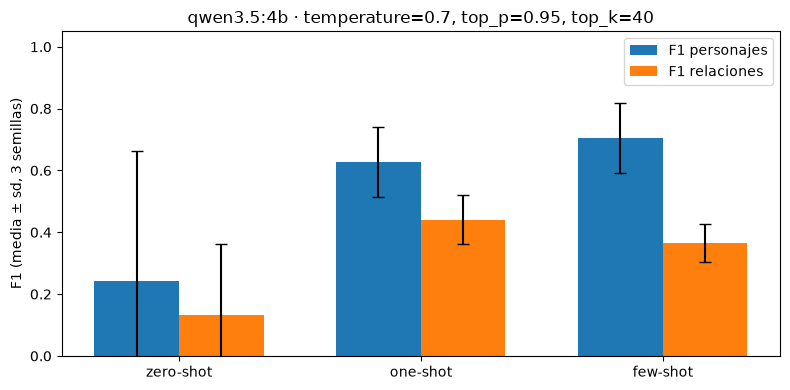

In [19]:
condiciones = ["zero", "one", "few"]
x = range(len(condiciones))
ancho = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
for desplazamiento, clave, etiqueta in [(-ancho / 2, "f1_personajes", "F1 personajes"),
                                         (ancho / 2, "f1_relaciones", "F1 relaciones")]:
    medias, errores = [], []
    for cond in condiciones:
        valores = [r[clave] for r in resultados if r["condicion"] == cond]
        medias.append(statistics.mean(valores))
        errores.append(statistics.stdev(valores) if len(valores) > 1 else 0.0)
    ax.bar([i + desplazamiento for i in x], medias, ancho, yerr=errores, capsize=4, label=etiqueta)

ax.set_xticks(list(x), ["zero-shot", "one-shot", "few-shot"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 (media ± sd, 3 semillas)")
ax.set_title(f"qwen3.5:4b · temperature={TEMPERATURE}, top_p={TOP_P}, top_k={TOP_K}")
ax.legend()
plt.tight_layout()
plt.show()


**Análisis.** La hipótesis de orden se sostiene entre zero-shot y los otros dos (0.19 frente a 0.53), pero one-shot y few-shot empatan. Few-shot tiene menos dispersión (0.03 frente a 0.09) y salidas más cortas (273 tokens frente a 438); one-shot añadió más extras (1.33 frente a 0.67: grupos como «las mujeres de la aldea»). Con `format`, la validez de zero-shot sube de 0.33 a 1.00, como se esperaba.


## 13. Conclusiones

### Respuestas

**`temperature`, `top_p` y `top_k`.** Solo los extremos hicieron daño: `temperature=1.5` y `top_k=100` rompieron una de tres corridas. Entre `top_p` 0.3, 0.7 y 0.95 no hubo diferencia distinguible, y `temperature=0.2` quedó algo por debajo de `0.7` (0.47 frente a 0.53). Se mantuvo la configuración base (`0.7`, `0.95`, `40`).

**Reproducibilidad y semilla.** Con la misma semilla, la salida fue idéntica. Entre semillas cambiaron validez, longitud y personajes. No se separó la semilla de la temperatura: la sección 7 usa 0.2 y las demás 0.7, así que no se afirma más.

**Ejemplos.** Zero-shot fue válido 1 de 3 veces; one-shot y few-shot, 3 de 3, con el mismo puntaje (0.53). Los ejemplos mejoraron la validez, no la regla de menciones, y en una corrida few-shot copió nombres de los ejemplos.

**Límites de salida y formato.** `num_predict` no causó los JSON incompletos: el modelo omite la llave final y termina por `stop`. `format` garantiza la forma, pero no el criterio de personajes.

**Recomendación.** Para este pasaje y modelo conviene few-shot (menor dispersión) u one-shot, con `temperature=0.7`, `top_p=0.95` y `top_k=40`. Si el parseo no puede fallar, se añade `format`.

### Limitaciones

- Un modelo, un pasaje y tres semillas: las desviaciones son estimaciones gruesas.
- La referencia refleja una sola lectura del capítulo, la del autor.
- La comparación es por nombre completo y no evalúa el texto de la relación.
- Los ejemplos fueron inventados por el autor; otros podrían cambiar el resultado.
- Los barridos se hicieron en few-shot y con las otras perillas en su base, así que no exploran interacciones.
- Los reintentos de la sección 10 cambian la semilla; no es un experimento limpio.
- No se probaron la contradicción `system`/`user`, `think=True` ni otros modelos.
- La reproducibilidad no se probó en otro equipo.


## Anexo A. Salida de la mejor corrida

La mejor corrida válida de la sección 9, ya parseada.


In [20]:
validos = [r for r in resultados if r["json_valido"]]
if validos:
    mejor = max(validos, key=lambda r: r["puntaje"])
    print(f"{mejor['condicion']} seed={mejor['seed']} puntaje={mejor['puntaje']:.2f}\n")
    print(json.dumps(parsear(mejor["texto"]), ensure_ascii=False, indent=2))
else:
    print("Ninguna corrida de la sección 9 produjo JSON válido.")

one seed=3 puntaje=0.59

{
  "personajes": [
    {
      "nombre": "Aureliano Buendía"
    },
    {
      "nombre": "José Arcadio Buendía"
    },
    {
      "nombre": "Úrsula Iguarán"
    },
    {
      "nombre": "Melquíades"
    },
    {
      "nombre": "Sir Francis Drake"
    },
    {
      "nombre": "El primer Aureliano Buendía"
    },
    {
      "nombre": "Las mujeres de la aldea"
    },
    {
      "nombre": "Los hombres del pueblo"
    }
  ],
  "relaciones": [
    {
      "sujeto": "Aureliano Buendía",
      "relacion": "hijo de",
      "objeto": "José Arcadio Buendía"
    },
    {
      "sujeto": "El coronel Aureliano Buendía",
      "relacion": "hijo de",
      "objeto": "José Arcadio Buendía"
    },
    {
      "sujeto": "José Arcadio Buendía",
      "relacion": "hijo de",
      "objeto": "El primer Aureliano Buendía"
    },
    {
      "sujeto": "José Arcadio Buendía",
      "relacion": "hermano de",
      "objeto": "Aureliano Buendía"
    },
    {
      "sujeto": "José Arc

## Anexo B. Salidas inválidas

Si hubo salidas que no pasaron la validación, se muestra el comienzo de la primera, para ver qué falló.


In [21]:
invalidas = [r for r in barrido + resultados if not r["json_valido"]]
print(f"Salidas inválidas: {len(invalidas)} de {len(barrido) + len(resultados)}")
if invalidas:
    print(invalidas[0]["texto"][:600])

Salidas inválidas: 4 de 36
{"personajes": [{"nombre": "Aureliano Buendía"}, {"nombre": "José Arcadio Buendía"}, {"nombre": "Úrsula Iguarán"}, {"nombre": "Ramón Soto"}, {"nombre": "Julián"}, {"nombre": "Melquíades"}, {"nombre": "Elena Castro"}], "relaciones": [{"sujeto": "Aureliano Buendía", "relacion": "descendiente de", "objeto": "José Arcadio Buendía"}, {"sujeto": "Ramón Soto", "relacion": "padre de", "objeto": "Lucía"}, {"sujeto": "Lucía", "relacion": "esposa de", "objeto": "Ignacio Vera"}, {"sujeto": "Úrsula Iguarán", "relacion": "cónyuge de", "objeto": "José Arcadio Buendía"}, {"sujeto": "Melquíades", "relacion": "
